<a href="https://colab.research.google.com/github/Jagrutibawiskar/Stock-Price-Prediction-and-Sentiment-Analysis-Using-Machine-Learning/blob/main/Stock_Price_Prediction_and_Sentiment_Analysis_Using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip install yfinance transformers vaderSentiment scikit-learn pandas matplotlib seaborn newsapi-python


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 9.1 MB/s eta 0:00:00


# This installs the necessary libraries for the project:

yfinance: For fetching historical stock data.

transformers: For any future NLP models.

vaderSentiment: For performing sentiment analysis on news articles.

scikit-learn: For machine learning models and utilities.

pandas: For data manipulation.

matplotlib and seaborn: For visualizing data.

newsapi-python: For fetching news articles.

plotly: For interactive plotting (though it's installed, it's not used in the current code).

In [8]:
import yfinance as yf
import pandas as pd
from newsapi import NewsApiClient
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import numpy as np
!pip install plotly


# Importing all the necessary libraries needed for data fetching, sentiment analysis, machine learning, and visualization.

In [9]:
# Fetch stock data (AAPL in this example)
stock_data = yf.download('AAPL', start='2020-01-01', end='2025-01-01')

# Display the stock data
print(stock_data.head())


[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.796021  72.856613  71.545387  71.799873  135480400
2020-01-03  72.088287  72.851753  71.862884  72.020424  146322800
2020-01-06  72.662704  72.701485  70.953995  71.206062  118387200
2020-01-07  72.320969  72.929314  72.100410  72.672402  108872000
2020-01-08  73.484344  73.787308  72.022850  72.022850  132079200


The yfinance library is used to download stock data for Apple Inc. (AAPL) for the specified time range (from January 1, 2020, to January 1, 2025).

The downloaded data includes open, close, high, low prices, and volume.

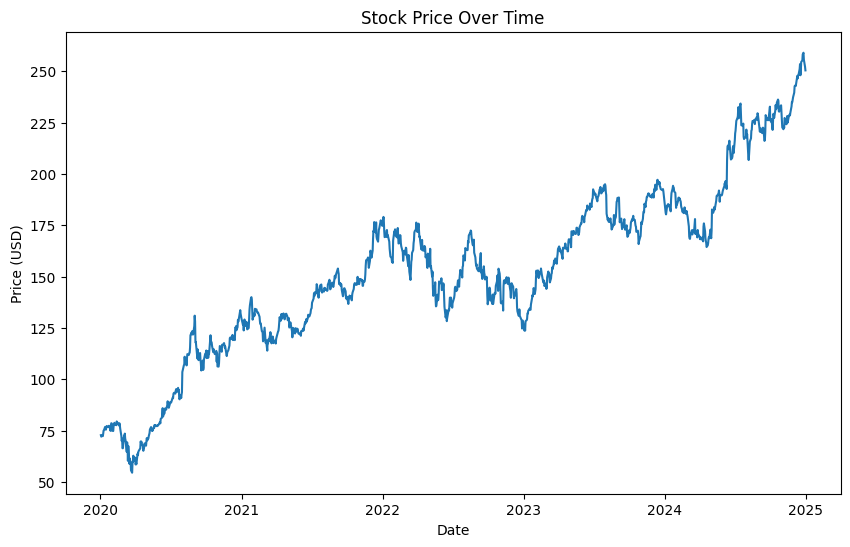

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(stock_data['Close'])
plt.title('Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.show()


# The code uses matplotlib to plot the stock's closing price over time.

In [12]:
# Initialize NewsAPI (Replace with your own API Key)
newsapi = NewsApiClient(api_key='d6a8be7e8f814b22a610392523a7086c')

# Fetch news articles about Apple
articles = newsapi.get_everything(q='Apple', language='en', sort_by='publishedAt', page_size=100)

# Extract headlines and publication dates
news_data = pd.DataFrame([{
    'published_date': article['publishedAt'],
    'title': article['title'],
    'description': article['description']
} for article in articles['articles']])

# Convert 'published_date' to datetime format
news_data['published_date'] = pd.to_datetime(news_data['published_date'])

# Display the news data
print(news_data.head())


             published_date  \
0 2025-01-12 12:51:36+00:00   
1 2025-01-12 12:46:25+00:00   
2 2025-01-12 12:18:01+00:00   
3 2025-01-12 12:13:08+00:00   
4 2025-01-12 12:12:25+00:00   

                                               title  \
0  Veteran fund manager issues stark S&P 500 warn...   
1  Video: Brett Favre Says He Was Wrong on Aaron ...   
2  Microsoft Weekly: dirty Bing tricks, the year ...   
3  Smart glasses enter new era with sleeker desig...   
4  Your Guide to Apple Intelligence Summaries in ...   

                                         description  
0  Make no mistake: this is the Age of the Magnif...  
1  Hall of Fame quarterback Brett Favre is confid...  
2  Former Microsoft engineers pedaling piracy onl...  
3  Smart glasses enter new era with sleeker desig...  
4  Here's how to summarize emails, messages and m...  


The NewsApiClient is initialized with a valid API key.

We use get_everything() to fetch news articles related to "Apple", sort them by the publication date, and limit the number of articles to 100.

A DataFrame is created with news articles, extracting the published date, title, and description.

The published_date is converted to a datetime object for easier filtering later.

In [13]:
# Initialize sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Function to get sentiment score
def get_sentiment_score(text):
    return analyzer.polarity_scores(text)['compound']

# Apply sentiment analysis to the news descriptions
news_data['sentiment_score'] = news_data['description'].apply(lambda x: get_sentiment_score(str(x)))

# Display the news data with sentiment scores
print(news_data[['published_date', 'title', 'sentiment_score']].head())


             published_date  \
0 2025-01-12 12:51:36+00:00   
1 2025-01-12 12:46:25+00:00   
2 2025-01-12 12:18:01+00:00   
3 2025-01-12 12:13:08+00:00   
4 2025-01-12 12:12:25+00:00   

                                               title  sentiment_score  
0  Veteran fund manager issues stark S&P 500 warn...           0.8965  
1  Video: Brett Favre Says He Was Wrong on Aaron ...           0.8176  
2  Microsoft Weekly: dirty Bing tricks, the year ...          -0.5267  
3  Smart glasses enter new era with sleeker desig...           0.4939  
4  Your Guide to Apple Intelligence Summaries in ...           0.5209  


The VaderSentiment analyzer is used to extract the sentiment score from the news article descriptions.

The sentiment score (compound) can range from -1 (negative) to +1 (positive), with 0 being neutral.

In [14]:
# Filter news based on sentiment score (example: select positive articles)
positive_news = news_data[news_data['sentiment_score'] > 0.1]

# Filter news by date range (example: select news from 2023)
news_data['published_date'] = pd.to_datetime(news_data['published_date'])
filtered_news = news_data[(news_data['published_date'] >= '2020-01-01') & (news_data['published_date'] <= '2025-01-01')]

# Display filtered news
print("Filtered Positive News Articles:")
print(positive_news[['published_date', 'title', 'sentiment_score']])

print("\nFiltered News Articles from 2024:")
print(filtered_news[['published_date', 'title', 'sentiment_score']])


Filtered Positive News Articles:
              published_date  \
0  2025-01-12 12:51:36+00:00   
1  2025-01-12 12:46:25+00:00   
3  2025-01-12 12:13:08+00:00   
4  2025-01-12 12:12:25+00:00   
6  2025-01-12 12:04:16+00:00   
7  2025-01-12 12:00:24+00:00   
8  2025-01-12 12:00:23+00:00   
10 2025-01-12 12:00:07+00:00   
11 2025-01-12 12:00:00+00:00   
13 2025-01-12 12:00:00+00:00   
15 2025-01-12 11:56:29+00:00   
16 2025-01-12 11:52:58+00:00   
17 2025-01-12 11:49:40+00:00   
19 2025-01-12 11:30:00+00:00   
24 2025-01-12 11:10:00+00:00   
26 2025-01-12 11:03:55+00:00   
28 2025-01-12 11:01:08+00:00   
29 2025-01-12 11:00:00+00:00   
33 2025-01-12 10:38:52+00:00   
37 2025-01-12 10:12:51+00:00   
38 2025-01-12 10:11:43+00:00   
41 2025-01-12 10:00:00+00:00   
43 2025-01-12 09:21:49+00:00   
46 2025-01-12 09:11:00+00:00   
47 2025-01-12 09:10:52+00:00   
50 2025-01-12 09:02:02+00:00   
52 2025-01-12 08:56:26+00:00   
53 2025-01-12 08:52:33+00:00   
54 2025-01-12 08:43:23+00:00   
55 2025

Filters news articles to get only positive articles, defined as having a sentiment score greater than 0.1.

Filters news articles within the date range from January 1, 2020, to January 1, 2025.

In [15]:
# Ensure stock_data has 'Date' column and is in datetime format
# stock_data.reset_index(inplace=True) # This line is causing the error
# Check if 'Date' is already in columns, and if not, reset the index
if 'Date' not in stock_data.columns:
    stock_data.reset_index(inplace=True)
    stock_data['Date'] = pd.to_datetime(stock_data['Date'])
else:
    stock_data['Date'] = pd.to_datetime(stock_data['Date'])

# Instead of tz_convert, use tz_localize to remove timezone information:
news_data['published_date'] = news_data['published_date'].dt.tz_localize(None)

# Convert stock_data columns to single level index
stock_data.columns = stock_data.columns.get_level_values(0) # OR
# stock_data.columns = ['_'.join(col).strip() for col in stock_data.columns.values]

# Merge stock_data with sentiment scores from news_data
merged_data = pd.merge(stock_data, news_data[['published_date', 'sentiment_score']],
                       left_on='Date', right_on='published_date', how='left')

# Fill missing sentiment values with 0 (neutral sentiment)
merged_data['sentiment_score'].fillna(0, inplace=True)

# Final merged data
print("Merged Data Head:")
print(merged_data.head())


Merged Data Head:
        Date      Close       High        Low       Open     Volume  \
0 2020-01-02  72.796021  72.856613  71.545387  71.799873  135480400   
1 2020-01-03  72.088287  72.851753  71.862884  72.020424  146322800   
2 2020-01-06  72.662704  72.701485  70.953995  71.206062  118387200   
3 2020-01-07  72.320969  72.929314  72.100410  72.672402  108872000   
4 2020-01-08  73.484344  73.787308  72.022850  72.022850  132079200   

  published_date  sentiment_score  
0            NaT              0.0  
1            NaT              0.0  
2            NaT              0.0  
3            NaT              0.0  
4            NaT              0.0  


<ipython-input-15-1f4593ac95fc>:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_data['sentiment_score'].fillna(0, inplace=True)


We check if the Date column already exists in the stock data. If it doesn't, we reset the index and assign the index to the Date column.

We ensure that the Date column is in the proper datetime format to facilitate merging.

We remove any timezone information from the published_date to ensure that the dates align correctly between stock data and news data.

The stock data and sentiment data are merged based on the Date and published_date.

Missing sentiment scores are filled with 0 (neutral sentiment).

In [16]:
# Add moving average feature (7-day window)
merged_data['moving_avg'] = merged_data['Close'].rolling(window=7).mean()

# Add volatility feature (7-day window standard deviation)
merged_data['volatility'] = merged_data['Close'].rolling(window=7).std()

# Display the new features
print(merged_data[['Date', 'Close', 'moving_avg', 'volatility']].head())



        Date      Close  moving_avg  volatility
0 2020-01-02  72.796021         NaN         NaN
1 2020-01-03  72.088287         NaN         NaN
2 2020-01-06  72.662704         NaN         NaN
3 2020-01-07  72.320969         NaN         NaN
4 2020-01-08  73.484344         NaN         NaN


Moving Average (7-day window): A smoothing technique that takes the average closing price of the last 7 days to reduce noise.

Volatility (7-day window standard deviation): A measure of the variability in stock prices over the past 7 days.

In [17]:
# Use 'sentiment_score', 'moving_avg', and 'volatility' to predict 'Close' price
features = ['sentiment_score', 'moving_avg', 'volatility']
X = merged_data[features]  # Features

# Align y to have the same number of rows as X
y = merged_data['Close'].shift(-1)  # Target variable (next day's closing price)

# Drop rows with NaN values in either X or y
merged_data_cleaned = pd.concat([X, y], axis=1).dropna()

# Separate features and target from the cleaned data
X = merged_data_cleaned[features]
y = merged_data_cleaned['Close']

# Now X and y should have the same number of samples
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Display the split data
print(X_train.head())


    sentiment_score  moving_avg  volatility
6               0.0   73.373202    1.277750
7               0.0   73.948312    1.781397
8               0.0   74.476331    1.683262
9               0.0   74.875898    1.503350
10              0.0   75.459317    1.079190


We define the features (sentiment score, moving average, and volatility) and the target variable (next day's stock closing price).

We use .shift(-1) to predict the stock price for the next day.

We concatenate the features (X) and target variable (y) and drop any rows with missing values.

We split the data into training (80%) and testing (20%) sets.

In [18]:
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error: {mae}')


Mean Absolute Error: 4.037821150141641


A Linear Regression model is trained using the training data.

We make predictions (y_pred) on the test data and calculate the Mean Absolute Error (MAE) to evaluate the model's performance.

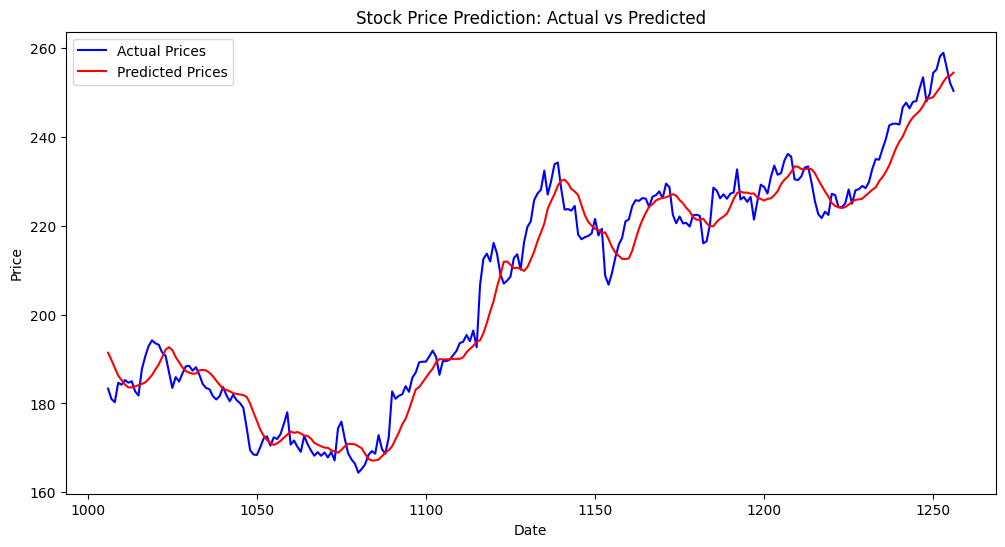

In [19]:
# Plot the predicted vs actual values
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test.values, label='Actual Prices', color='blue')
plt.plot(y_test.index, y_pred, label='Predicted Prices', color='red')
plt.legend()
plt.title('Stock Price Prediction: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()


# A plot is created comparing the actual stock prices (y_test) and predicted prices (y_pred) on the test set.

In [20]:
!pip install transformers

In [21]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch

# Load BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('nlptown/bert-base-multilingual-uncased-sentiment')
model = BertForSequenceClassification.from_pretrained('nlptown/bert-base-multilingual-uncased-sentiment')

# Function to get BERT sentiment score
def get_bert_sentiment_score(text):
    inputs = tokenizer.encode(text, return_tensors='pt', truncation=True, max_length=512)
    outputs = model(inputs)
    sentiment_score = torch.argmax(outputs.logits).item()
    return sentiment_score

# Apply BERT sentiment analysis to the news descriptions
news_data['sentiment_score_bert'] = news_data['description'].apply(lambda x: get_bert_sentiment_score(str(x)))

# Display the news data with BERT sentiment scores
print(news_data[['published_date', 'title', 'sentiment_score_bert']].head())


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

       published_date                                              title  \
0 2025-01-12 12:51:36  Veteran fund manager issues stark S&P 500 warn...   
1 2025-01-12 12:46:25  Video: Brett Favre Says He Was Wrong on Aaron ...   
2 2025-01-12 12:18:01  Microsoft Weekly: dirty Bing tricks, the year ...   
3 2025-01-12 12:13:08  Smart glasses enter new era with sleeker desig...   
4 2025-01-12 12:12:25  Your Guide to Apple Intelligence Summaries in ...   

   sentiment_score_bert  
0                     4  
1                     3  
2                     0  
3                     1  
4                     4  


This section uses the BERT model (specifically, nlptown/bert-base-multilingual-uncased-sentiment) to perform sentiment analysis.

It tokenizes the text and predicts a sentiment score using the BERT model.

The sentiment scores are added to the news_data DataFrame as sentiment_score_bert.

# Summary:

The code above fetches stock data and news articles, performs sentiment analysis on the news using both Vader and BERT models, merges the data, and then uses linear regression to predict stock prices based on sentiment scores, moving averages, and volatility. It also visualizes stock prices and model predictions.